In [1]:
import requests
import os
from dotenv import load_dotenv

# Cargar API key desde archivo .env
load_dotenv()
API_KEY = os.getenv("USDA_API_KEY")
BASE_URL = "https://api.nal.usda.gov/fdc/v1"

# Verificar conexión
response = requests.get(
    f"{BASE_URL}/foods/search",
    params={
        "api_key": API_KEY,
        "query": "breakfast cereal",
        "dataType": ["Branded"],
        "pageSize": 5
    }
)
if response.status_code == 200:
    data = response.json()
    print(f"✓ Conexión exitosa")
    print(f"Total productos: {data['totalHits']}")
    for food in data['foods']:
        print(f"  - {food['description']}")
else:
    print(f"✗ Error: {response.status_code}")

✓ Conexión exitosa
Total productos: 14739
  - Bluey Breakfast Cereal
  - BREAKFAST PACK CEREAL
  - Cheerios Breakfast Cereal
  - Cheerios Breakfast Cereal
  - Total Breakfast Cereal


In [2]:
import pandas as pd
import time

def extraer_cereales(api_key, max_productos=15000):
    """Extrae todos los cereales de USDA"""
    todos_los_productos = []
    page = 1
    page_size = 200  # Máximo permitido por la API
    
    while len(todos_los_productos) < max_productos:
        response = requests.get(
            f"{BASE_URL}/foods/search",
            params={
                "api_key": api_key,
                "query": "cereal",
                "dataType": ["Branded"],
                "pageSize": page_size,
                "pageNumber": page
            }
        )
        
        if response.status_code != 200:
            print(f"Error en página {page}: {response.status_code}")
            break
            
        data = response.json()
        productos = data.get('foods', [])
        
        if not productos:
            break
            
        todos_los_productos.extend(productos)
        print(f"Página {page}: {len(productos)} productos (Total: {len(todos_los_productos)})")
        
        page += 1
        time.sleep(0.5)  # Pausa para no saturar la API
    
    return todos_los_productos

# Ejecutar extracción
print("Iniciando extracción...")
productos = extraer_cereales(API_KEY)
print(f"\nTotal extraído: {len(productos)} productos")

Iniciando extracción...
Página 1: 200 productos (Total: 200)
Página 2: 200 productos (Total: 400)
Página 3: 200 productos (Total: 600)
Página 4: 200 productos (Total: 800)
Página 5: 200 productos (Total: 1000)
Página 6: 200 productos (Total: 1200)
Página 7: 200 productos (Total: 1400)
Página 8: 200 productos (Total: 1600)
Página 9: 200 productos (Total: 1800)
Página 10: 200 productos (Total: 2000)
Página 11: 200 productos (Total: 2200)
Página 12: 200 productos (Total: 2400)
Página 13: 200 productos (Total: 2600)
Página 14: 200 productos (Total: 2800)
Página 15: 200 productos (Total: 3000)
Página 16: 200 productos (Total: 3200)
Página 17: 200 productos (Total: 3400)
Página 18: 200 productos (Total: 3600)
Página 19: 200 productos (Total: 3800)
Página 20: 200 productos (Total: 4000)
Página 21: 200 productos (Total: 4200)
Página 22: 200 productos (Total: 4400)
Página 23: 200 productos (Total: 4600)
Página 24: 200 productos (Total: 4800)
Página 25: 200 productos (Total: 5000)
Página 26: 200

In [3]:
# Extraer campos relevantes
datos = []
for p in productos:
    datos.append({
        'fdc_id': p.get('fdcId'),
        'description': p.get('description'),
        'brand_owner': p.get('brandOwner'),
        'serving_size': p.get('servingSize'),
        'serving_size_unit': p.get('servingSizeUnit'),
        'food_category': p.get('foodCategory'),
        # Nutrientes
        **{n['nutrientName']: n.get('value') for n in p.get('foodNutrients', [])}
    })

# Crear DataFrame y guardar
df = pd.DataFrame(datos)
df.to_csv('/Users/aracelli/Documents/GitHub/TFM-similitud-nutricional/data/raw/cereales_raw.csv', index=False)

print(f"Guardado: {len(df)} productos")
print(f"Columnas: {len(df.columns)}")
print(df.head())

Guardado: 11995 productos
Columnas: 81
    fdc_id description                     brand_owner  serving_size  \
0  2642006      CEREAL  President Baking Company, Inc.          37.0   
1  2107531      CEREAL            The Kellogg Company           29.0   
2  1952060      CEREAL       Post Consumer Brands, LLC          28.0   
3  1889809      CEREAL       Post Consumer Brands, LLC          30.0   
4  2140770      CEREAL            The Kellogg Company           53.0   

  serving_size_unit food_category  Protein  Total lipid (fat)  \
0               GRM        Cereal     5.41               0.00   
1                 g        Cereal     6.90               0.00   
2                 g        Cereal    10.70               5.36   
3                 g        Cereal     3.33               3.33   
4                 g        Cereal     5.66               1.89   

   Carbohydrate, by difference  Energy  ...  Valine  Arginine  Histidine  \
0                         89.2   351.0  ...     NaN       NaN

In [4]:
# Columnas clave 
cols_nutricionales = ['Energy', 'Protein', 'Carbohydrate, by difference', 
                      'Total lipid (fat)', 'Fatty acids, total saturated',
                      'Fiber, total dietary', 'Total Sugars', 'Sodium, Na']

cols_descriptivas = ['fdc_id', 'description', 'brand_owner', 'food_category']

# Verificar disponibilidad
print("=== VARIABLES NUTRICIONALES ===")
for col in cols_nutricionales:
    pct = (df[col].notna().sum() / len(df)) * 100
    print(f"{col}: {pct:.1f}%")

# Resumen estadístico
print("\n=== ESTADÍSTICAS ===")
df[cols_nutricionales].describe()

=== VARIABLES NUTRICIONALES ===
Energy: 99.1%
Protein: 99.5%
Carbohydrate, by difference: 99.3%
Total lipid (fat): 99.5%
Fatty acids, total saturated: 99.1%
Fiber, total dietary: 99.3%
Total Sugars: 99.3%
Sodium, Na: 99.3%

=== ESTADÍSTICAS ===


,Energy,Protein,"Carbohydrate, by difference",Total lipid (fat),"Fatty acids, total saturated","Fiber, total dietary",Total Sugars,"Sodium, Na"
count,11887.000000,11939.000000,11909.000000,11935.000000,11883.000000,11910.000000,11911.000000,1.191300e+04
mean,396.648355,9.133657,71.689216,9.488891,2.385894,6.739522,23.985593,6.310052e+02
std,342.816663,7.941232,57.708095,12.706557,4.756439,6.079120,23.114338,1.522751e+04
min,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,371.000000,5.410000,65.000000,3.570000,0.000000,3.300000,15.000000,1.300000e+02
50%,390.000000,8.000000,74.400000,6.410000,0.980000,6.700000,24.000000,3.390000e+02
75%,418.000000,10.700000,82.000000,12.900000,2.830000,9.300000,33.000000,4.860000e+02
max,25000.000000,400.000000,4100.000000,800.000000,200.000000,300.000000,1400.000000,1.300000e+06


In [5]:
# Seleccionar columnas finales
cols_final = cols_descriptivas + cols_nutricionales
df_clean = df[cols_final].copy()

# Eliminar filas con missings en variables nutricionales
df_clean = df_clean.dropna(subset=cols_nutricionales)

print(f"Productos originales: {len(df)}")
print(f"Productos limpios: {len(df_clean)}")
print(f"Eliminados: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

# Guardar dataset limpio
df_clean.to_csv('/Users/aracelli/Documents/GitHub/TFM-similitud-nutricional/data/processed/cereales_clean.csv', index=False)
print("\nGuardado en data/processed/cereales_clean.csv")

Productos originales: 11995
Productos limpios: 11663
Eliminados: 332 (2.8%)

Guardado en data/processed/cereales_clean.csv


In [6]:
# Resumen estadístico
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df_clean[cols_nutricionales].describe().round(2)

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Energy,Protein,"Carbohydrate, by difference",Total lipid (fat),"Fatty acids, total saturated","Fiber, total dietary",Total Sugars,"Sodium, Na"
count,11663.00,11663.00,11663.00,11663.00,11663.00,11663.00,11663.00,11663.0
mean,396.91,9.14,71.76,9.47,2.36,6.75,23.99,607.2
std,345.57,7.96,58.19,12.77,4.75,6.11,23.25,15004.8
min,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.0
25%,371.00,5.41,65.10,3.57,0.00,3.30,15.00,133.0
50%,390.00,8.00,74.40,6.41,0.96,6.70,24.10,339.0
75%,418.00,10.70,82.00,12.90,2.73,9.30,33.00,486.0
max,25000.00,400.00,4100.00,800.00,200.00,300.00,1400.00,1300000.0


In [7]:
# Rangos válidos por 100g
rangos_validos = {
    'Energy': (0, 900),           # kcal
    'Protein': (0, 100),          # g
    'Carbohydrate, by difference': (0, 100),
    'Total lipid (fat)': (0, 100),
    'Fatty acids, total saturated': (0, 100),
    'Fiber, total dietary': (0, 100),
    'Total Sugars': (0, 100),
    'Sodium, Na': (0, 10000)      # mg
}

# Filtrar outliers
df_valid = df_clean.copy()
for col, (min_val, max_val) in rangos_validos.items():
    antes = len(df_valid)
    df_valid = df_valid[(df_valid[col] >= min_val) & (df_valid[col] <= max_val)]
    eliminados = antes - len(df_valid)
    if eliminados > 0:
        print(f"{col}: {eliminados} outliers eliminados")

print(f"\nProductos finales: {len(df_valid)}")
print(f"Eliminados total: {len(df_clean) - len(df_valid)}")

# Guardar versión final
df_valid.to_csv('/Users/aracelli/Documents/GitHub/TFM-similitud-nutricional/data/processed/cereales_clean.csv', index=False)

Energy: 8 outliers eliminados
Carbohydrate, by difference: 37 outliers eliminados
Total lipid (fat): 1 outliers eliminados
Sodium, Na: 9 outliers eliminados

Productos finales: 11608
Eliminados total: 55


In [8]:
print("=== ESTADÍSTICAS FINALES ===")
df_valid[cols_nutricionales].describe().round(2)

=== ESTADÍSTICAS FINALES ===


,Energy,Protein,"Carbohydrate, by difference",Total lipid (fat),"Fatty acids, total saturated","Fiber, total dietary",Total Sugars,"Sodium, Na"
count,11608.00,11608.00,11608.00,11608.00,11608.00,11608.00,11608.00,11608.00
mean,390.82,9.01,70.66,9.32,2.32,6.69,23.61,328.86
std,66.78,5.89,16.17,8.61,3.84,4.52,13.18,246.00
min,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00
25%,371.00,5.41,65.00,3.57,0.00,3.30,15.00,132.00
50%,390.00,8.00,74.40,6.41,0.96,6.70,24.00,339.00
75%,418.00,10.70,81.80,12.90,2.73,9.30,32.80,486.00
max,747.00,85.70,97.60,97.50,41.70,70.70,93.80,8330.00


In [9]:
# Resumen final
print("=== RESUMEN DATASET ===")
print(f"Productos: {len(df_valid)}")
print(f"Variables: {len(df_valid.columns)}")
print(f"\nArchivo guardado: data/processed/cereales_clean.csv")
print("\n✓ Extracción completada")

=== RESUMEN DATASET ===
Productos: 11608
Variables: 12

Archivo guardado: data/processed/cereales_clean.csv

✓ Extracción completada


In [10]:
# Guardar 
df_valid.to_csv('../data/processed/cereales_clean.csv', index=False)
print(f"Verificación: {os.path.exists('../data/processed/cereales_clean.csv')}")

Verificación: True


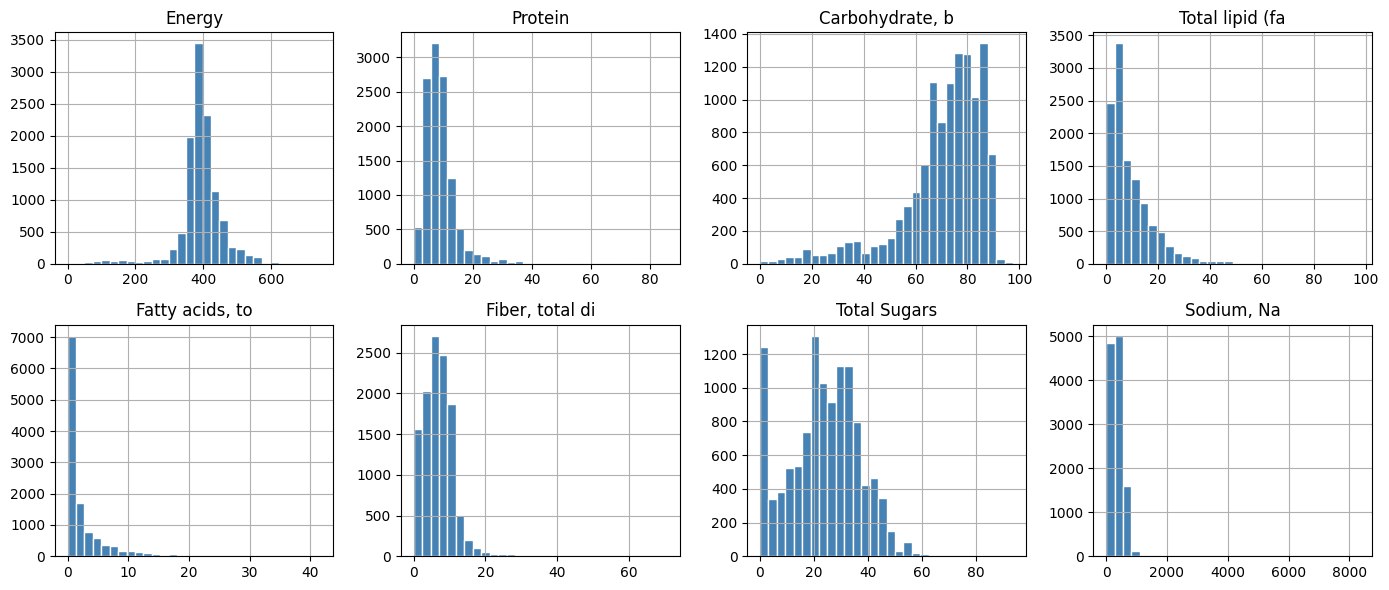

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_nutri = ['Energy', 'Protein', 'Carbohydrate, by difference', 
              'Total lipid (fat)', 'Fatty acids, total saturated',
              'Fiber, total dietary', 'Total Sugars', 'Sodium, Na']

# Distribuciones
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, col in enumerate(cols_nutri):
    ax = axes[i//4, i%4]
    df_valid[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col[:15])
plt.tight_layout()
plt.savefig('../docs/histogramas.png')
plt.show()

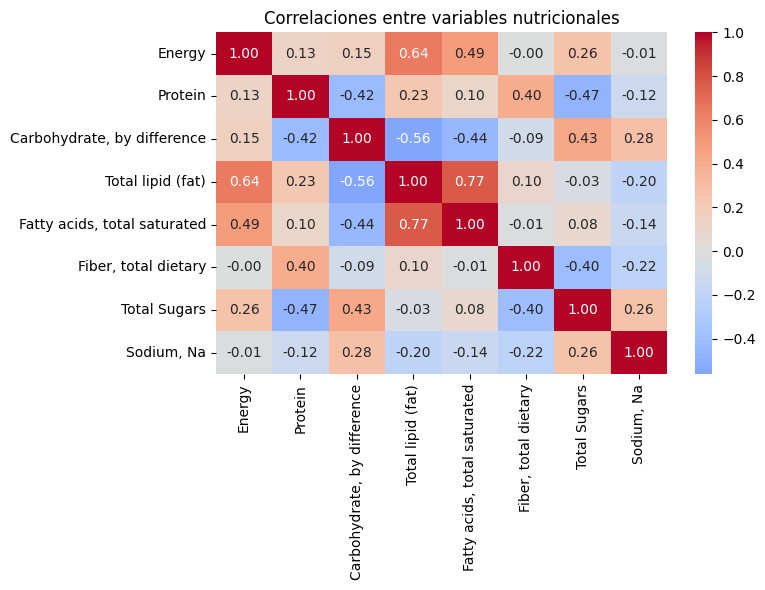

In [12]:
# Correlaciones
plt.figure(figsize=(8, 6))
corr = df_valid[cols_nutri].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlaciones entre variables nutricionales')
plt.tight_layout()
plt.savefig('../docs/correlaciones.png')
plt.show()